In [ ]:
# Bathymetry prediction on aerial/satellite images using bathy-U-Net
# Initial Pytorch Implementation: Panagiotis Agrafiotis (https://github.com/pagraf)
# Email: agrafiotis.panagiotis@gmail.com

# Description: magicbathy_unet.py is a simplified U-Net model modified for estimating water depth from RGB images. 
# The model retains the encoder-decoder structure with reduced layers and channels, using skip connections to 
# maintain spatial information during depth prediction. It outputs continuous values, suitable for depth estimation,
# even with limited annotated data.

# If you use this code please cite our paper: "Agrafiotis, P., Janowski, L., Skarlatos, D. & Demir, B. (2024) 
# MagicBathyNet: A Multimodal Remote Sensing Dataset for Bathymetry Prediction and Pixel-based Classification 
# in Shallow Waters, arXiv preprint arXiv:2405.15477, 2024."

# This .ipynb was structured inspired by the [DeepNetsForEO] (https://github.com/nshaud/DeepNetsForEO) repository.





# Attribution-NonCommercial-ShareAlike 4.0 International License

# Copyright (c) 2024 The MagicBathyNet Authors

# This license requires that reusers give credit to the creator. It allows reusers 
# to distribute, remix, adapt, and build upon the material in any medium or format,
# for noncommercial purposes only. If others modify or adapt the material, they 
# must license the modified material under identical terms.

# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
# IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
# FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
# AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
# LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
# OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
# SOFTWARE.


# This work is part of MagicBathy project funded by the European Union’s HORIZON Europe research and innovation 
# programme under the Marie Skłodowska-Curie GA 101063294. Work has been carried out at the Remote Sensing Image 
# Analysis group. For more information about the project visit https://www.magicbathy.eu/.



In [ ]:
## GPU
#Enable GPU with `Runtime->Change runtime type->Hardware Accelerator->GPU` in the top menu

In [45]:
# imports and stuff
import time
import numpy as np
from skimage import io
from glob import glob
from tqdm import tqdm_notebook as tqdm
from sklearn.metrics import confusion_matrix, precision_score, recall_score
import random
import itertools

# Matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

# Torch imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim
import torch.optim.lr_scheduler
import torch.nn.init
from torch.autograd import Variable

# Other imports
#import rasterio
# import gdal
from osgeo import gdal
import scipy
import cv2
from magicbathy_unet import *
import sys
from IPython.display import clear_output
import numpy.ma as ma
from torchvision.transforms import RandomCrop, Resize
from skimage.transform import resize, rotate, resize_local_mean
from sklearn.metrics import mean_squared_error
import scipy.ndimage 
import os
from skimage.transform import resize as skimage_resize

In [46]:
# insert your data folder path here
FOLDER = '/.../'
sys.path.append(FOLDER)

MAIN_FOLDER = FOLDER

BASE_DATA_FOLDER = '/Users/x-yq/Desktop/CV4RS/super-resolution/datasets/data/' # TODO: Needs to be correct
BASE_CONFIG_FOLDER = '/Users/x-yq/Desktop/CV4RS/super-resolution/configs/' # TODO: Needs to be correct

#RGB images and depth folders
DATA_FOLDER = '/Users/x-yq/Desktop/CV4RS/super-resolution/images/ft_an_bilinear/agia_napa/denorm/img_{}.tif' # MAIN_FOLDER + '.../img_{}.tif' TODO: location of the RGB images
LABEL_FOLDER = BASE_DATA_FOLDER + 'agia_napa/depth/spot6/depth_{}.tif' #  TODO: location of the depth images
# ERODED_FOLDER = BASE_DATA_FOLDER + 'agia_napa/depth/spot6/depth_{}.tif' # MAIN_FOLDER + '.../depth_{}.tif'

# Parameters

In [47]:
# Parameters

#set the dataset modality here

#dataset = "S2"
dataset = "SPOT6"
#dataset = "UAV"

if dataset == "UAV":
    norm_param = np.load('norm_param_aerial.npy')
    norm_param_depth = -11.0   #-30.443 FOR AGIA NAPA, -11 FOR PUCK LAGOON
    WINDOW_SIZE = (30, 30)
    STRIDE = 16
    BATCH_SIZE = 1
    MAIN_FOLDER = FOLDER
    train_images = ['409', '418', '350', '399', '361', '430', '380', '359', '371', '377', '379', '360', '368', '419', '389', '420', '401', '408', '352', '388', '362', '421', '412', '351', '349', '390', '400', '378']
    test_images = ['411', '387', '410', '398', '370', '369', '397']
    
elif dataset == "SPOT6":
    norm_param = np.load(BASE_CONFIG_FOLDER + 'norm_params/norm_param_s2_an.npy') # TODO: change between an and pl
    norm_param_depth = -30.433   #-30.443 FOR AGIA NAPA, -11 FOR PUCK LAGOON TODO: change between an and pl
    #norm_param_depth = -11.0
    WINDOW_SIZE = (30, 30)
    STRIDE = 2
    BATCH_SIZE = 1
    MAIN_FOLDER = FOLDER 
    train_images = ['409', '418', '350', '399', '361', '430', '380', '359', '371', '377', '379', '360', '368', '419', '389', '420', '401', '408', '352', '388', '362', '421', '412', '351', '349', '390', '400', '378']
    test_images = ['411', '387', '410', '398', '370', '369', '397']
    
elif dataset == "S2":
    norm_param = np.load('norm_param_s2_an.npy')
    norm_param_depth = -30.443   #-30.443 FOR AGIA NAPA, -11 FOR PUCK LAGOON
    WINDOW_SIZE = (18, 18)
    STRIDE = 2
    BATCH_SIZE = 1
    MAIN_FOLDER = FOLDER 
    train_images = ['409', '418', '350', '399', '361', '430', '380', '359', '371', '377', '379', '360', '368', '419', '389', '420', '401', '408', '352', '388', '362', '421', '412', '351', '349', '390', '400', '378']
    test_images = ['411', '387', '410', '398', '370', '369', '397']
    
print(norm_param)
print(norm_param.shape)

net = UNet_bathy(3, 1)
base_lr = 0.0001

CACHE = True # Store the dataset in-memory

[[   0.       0.       0.   ]
 [2311.665 2110.53  1796.814]]
(2, 3)



# Visualizing the dataset

In [4]:
# We load one tile from the dataset and we display it
# img = io.imread(BASE_DATA_FOLDER+'agia_napa/img/spot6/img_410.tif')
img = io.imread(DATA_FOLDER.format(410))
fig = plt.figure()
fig.add_subplot(121)
norm_img = (img - norm_param[0]) / (norm_param[1] - norm_param[0]) 
norm_img = norm_img[..., [2, 1, 0]]
plt.imshow(norm_img)
print(img.shape)

# We load the ground truth
gt = io.imread(BASE_DATA_FOLDER+'agia_napa/depth/spot6/depth_410.tif')
fig.add_subplot(122)
plt.imshow(gt/norm_param_depth)
# print(gt/norm_param_depth)

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/Users/x-yq/Desktop/CV4RS/super-resolution/images/pretrained2/puck_lagoon/denorm/img_410.tif'

We need to define some utils functions.

In [48]:
# Utils

def get_random_pos(img, window_shape):
    """ Extract of 2D random patch of shape window_shape in the image """
    w, h = window_shape
    W, H = img.shape[-2:]
    x1 = random.randint(0, W - w)
    x2 = x1 + w
    y1 = random.randint(0, H - h)
    y2 = y1 + h
    return x1, x2, y1, y2

def sliding_window(top, step=10, window_size=(20,20)):
    """ Slide a window_shape window across the image with a stride of step """
    for x in range(0, top.shape[0], step):
        if x + window_size[0] > top.shape[0]:
            x = top.shape[0] - window_size[0]
        for y in range(0, top.shape[1], step):
            if y + window_size[1] > top.shape[1]:
                y = top.shape[1] - window_size[1]
            yield x, y, window_size[0], window_size[1]
            
def count_sliding_window(top, step=10, window_size=(20,20)):
    """ Count the number of windows in an image """
    c = 0
    for x in range(0, top.shape[0], step):
        if x + window_size[0] > top.shape[0]:
            x = top.shape[0] - window_size[0]
        for y in range(0, top.shape[1], step):
            if y + window_size[1] > top.shape[1]:
                y = top.shape[1] - window_size[1]
            c += 1
    return c

def grouper(n, iterable):
    """ Browse an iterator by chunk of n elements """
    it = iter(iterable)
    while True:
        chunk = tuple(itertools.islice(it, n))
        if not chunk:
            return
        yield chunk

def metrics(predictions, gts):
    # Exclude 0 values from calculation
    non_zero_mask = predictions != 0
    
    # Calculate RMSE, MAE, and collect predictions and targets
    rmse = np.sqrt(np.mean(((predictions - gts) ** 2)[non_zero_mask]))
    mae = np.mean(np.abs((predictions - gts)[non_zero_mask]))
    std_dev = np.std((predictions - gts)[non_zero_mask])
    
    print("RMSE : {:.3f}m".format(rmse*-norm_param_depth))
    print("MAE : {:.3f}m".format(mae*-norm_param_depth))
    print("Std_Dev : {:.3f}m".format(std_dev*-norm_param_depth))
    print("---")
    
    return rmse

def read_geotiff(filename, b):
    ds = gdal.Open(filename)
    band = ds.GetRasterBand(b)
    arr = band.ReadAsArray()
    return arr, ds

def write_geotiff(filename, arr, in_ds):
    if arr.dtype == np.float32:
        arr_type = gdal.GDT_Float32
    else:
        arr_type = gdal.GDT_Int32

    driver = gdal.GetDriverByName("GTiff")
    out_ds = driver.Create(filename, arr.shape[1], arr.shape[0], 1, arr_type)
    out_ds.SetProjection(in_ds.GetProjection())
    out_ds.SetGeoTransform(in_ds.GetGeoTransform())
    band = out_ds.GetRasterBand(1)
    band.WriteArray(arr)
    band.FlushCache()
    band.ComputeStatistics(False)

# Load the Network on GPU

We can now instantiate the network using the specified parameters.

In [49]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
# torch.cuda.init()
#device = torch.device('cpu')
net = net.to(device)

In [54]:
crop_size = 256
pad_size = 32  # Define pad size here

def test(net, test_ids, all=True):
    # Use the network on the test set
    test_images = ((np.asarray(io.imread(DATA_FOLDER.format(id)), dtype='float32') - norm_param[0]) / (norm_param[1] - norm_param[0]) for id in test_ids)

    test_labels = [1 / norm_param_depth * np.asarray(io.imread(LABEL_FOLDER.format(id)), dtype='float32') for id in test_ids]
    eroded_labels = [1 / norm_param_depth * np.asarray(io.imread(LABEL_FOLDER.format(id)), dtype='float32') for id in test_ids]
    all_preds = []
    all_gts = []
    all_masked_preds = []
    all_masked_gts = []


    # Switch the network to inference mode
    net.eval()
    
    mse = None
    
    ratio = crop_size / WINDOW_SIZE[0]
    
    for img, gt, gt_e in tqdm(zip(test_images, test_labels, eroded_labels), total=len(test_ids), leave=False):
        img = scipy.ndimage.zoom(img, (ratio, ratio, 1), order=1)
        gt = scipy.ndimage.zoom(gt, (ratio, ratio), order=1)
        gt_e = scipy.ndimage.zoom(gt_e, (ratio, ratio), order=1)
        
        img = img[...,[2,1,0]]

        # Pad the image, ground truth, and eroded ground truth with reflection
        img = np.pad(img, ((pad_size, pad_size), (pad_size, pad_size), (0, 0)), mode='reflect')
        gt = np.pad(gt, ((pad_size, pad_size), (pad_size, pad_size)), mode='reflect')
        gt_e = np.pad(gt_e, ((pad_size, pad_size), (pad_size, pad_size)), mode='reflect')

        # Convert image to tensor
        #img_tensor = np.copy(img).transpose((2, 0, 1))
        img_tensor = np.copy(img).astype(np.float32).transpose((2, 0, 1))
        img_tensor = np.expand_dims(img_tensor, axis=0)
        img_tensor = torch.from_numpy(img_tensor).to(device)

        # Do the inference on the whole image
        with torch.no_grad():
            outs = net(img_tensor.float())
            pred = outs.data.cpu().numpy().squeeze()
            
        # Remove padding from prediction
        pred = pred[pad_size:-pad_size, pad_size:-pad_size]
        img = img[pad_size:-pad_size, pad_size:-pad_size]
        gt = gt[pad_size:-pad_size, pad_size:-pad_size]
        gt_e = gt_e[pad_size:-pad_size, pad_size:-pad_size]

        # Display the result
        clear_output()
        fig = plt.figure()
        fig.add_subplot(1, 3, 1)
        plt.imshow(np.asarray(255 * img, dtype='uint8'))
        fig.add_subplot(1, 3, 2)
        plt.imshow(pred)  
        fig.add_subplot(1, 3, 3)
        plt.imshow(gt)
        plt.show()
        
        # Generate mask for non-annotated pixels in depth data 
        gt_mask = (gt_e != 0).astype(np.float32) 
        gt_mask = torch.from_numpy(gt_mask) 
        gt_mask = gt_mask.unsqueeze(0)
        gt_mask = gt_mask.reshape(crop_size, crop_size)
        gt_mask = gt_mask.to(device) 

        img_mask = (img != 0).astype(np.float32) 
        img_mask = np.mean(img_mask, axis=2)
        img_mask = torch.from_numpy(img_mask)  
        #img_mask = img_mask.reshape(crop_size, crop_size)
        img_mask = img_mask.to(device) 
        
        print(gt_mask.shape)
        print(img_mask.shape)
        
        combined_mask = img_mask*gt_mask
      
        masked_pred = pred * combined_mask.cpu().numpy()
        masked_gt_e = gt_e * combined_mask.cpu().numpy()
        all_preds.append(pred)
        all_gts.append(gt_e)
        
        all_masked_preds.append(masked_pred)
        all_masked_gts.append(masked_gt_e)
        

        #clear_output()

        #metrics(masked_pred.ravel(), masked_gt_e.ravel())
        # print(f"RSME: {rmse*-norm_param_depth}")
    rmse = metrics(np.concatenate([p.ravel() for p in all_masked_preds]), np.concatenate([p.ravel() for p in all_masked_gts]).ravel())

    # Returning all predictions and ground truths if 'all' is set to True
    if all:
        return rmse, all_preds, all_gts
    else:
        return rmse  # Returning the final MSE for the test set


# Testing the network


In [51]:
existing_ids = []

for no in range(1, 1300):
    if os.path.exists(DATA_FOLDER.format(no)):
        if os.path.exists(LABEL_FOLDER.format(no)):
            existing_ids.append(no)

print(existing_ids)

[369, 370, 387, 397, 398, 410, 411]


In [52]:
# net.load_state_dict(torch.load('./model_final'))
net.load_state_dict(torch.load('weights/u_net/an', map_location=torch.device('cpu'))) # TODO: change weights/bathymetry_spot6_pl
net.to(device)

UNet_bathy(
  (encoder): Sequential(
    (0): DoubleConv(
      (double_conv): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU(inplace=True)
      )
    )
    (1): Down(
      (maxpool_conv): Sequential(
        (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (1): DoubleConv(
          (double_conv): Sequential(
            (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (1): ReLU(inplace=True)
            (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (3): ReLU(inplace=True)
          )
        )
      )
    )
    (2): Down(
      (maxpool_conv): Sequential(
        (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (1): DoubleConv(
          (double_conv): Sequential(
  

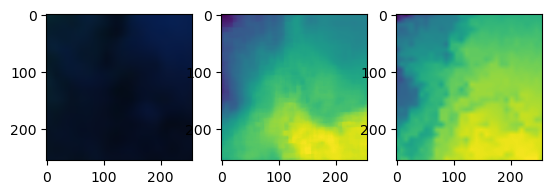

torch.Size([256, 256])
torch.Size([256, 256])
RMSE : 0.964m
MAE : 0.589m
Std_Dev : 0.929m
---


In [55]:
test_ids = [410] # 410, 2987
test_an = ['369', '370', '387', '397', '398', '410', '411']
test_pl_subset = [4, 12, 38, 59, 60, 61, 86, 88, 96, 98, 101, 107, 111, 116, 142, 147, 152, 155, 156, 162, 168, 169, 183, 184, 185, 186, 200, 201, 204, 212, 213, 219, 225, 231, 234, 236, 241, 245, 248, 249, 251, 253, 256, 259, 264, 273, 274, 276, 280, 281, 292, 293, 297, 298, 302, 304, 312, 313, 318, 319, 320]
test_pl = ['2987', '2707', '840', '293', '1510', '2667', '1720', '877', '1878', '3156', '358', '1829', '1121', '1044', '1274', '1107', '2814', '760', '2938', '253', '2647', '1760', '1848', '2065', '1983', '1176', '1408', '1618', '2632', '1264', '365', '876', '3267', '1985', '869', '2866', '676', '273', '185', '2120', '2846', '460', '2125', '3196', '345', '535', '1718', '2041', '2160', '1401', '2876', '952', '2577', '765', '3069', '2752', '1431', '2325', '496', '231', '2558', '12', '2951', '2106', '236', '2008', '837', '1182', '61', '475', '1287', '1662', '168', '1970', '341', '2480', '2678', '3194', '783', '2575', '868', '1446', '874', '1318', '1746', '1144', '2414', '2757', '2875', '3296', '1091', '281', '1596', '2042', '2163', '1427', '96', '543', '2723', '2610', '2728', '1045', '1313', '2885', '142', '1503', '867', '2677', '1252', '280', '2107', '1417', '1664', '3040', '1032', '2197', '780', '1193', '1148', '1635', '331', '999', '200', '147', '1137', '2362', '2488', '885', '318', '3176', '2935', '325', '1950', '2270', '2561', '1346', '1798', '59', '544', '1083', '2252', '3186', '248', '3151', '945', '2050', '552', '3142', '525', '1301', '2214', '3085', '274', '2347', '993', '213', '831', '2910', '2983', '416', '245', '302', '1066', '1677', '2758', '3088', '3160', '851', '2738', '1466', '1183', '2019', '2966', '1213', '3155', '1851', '1321', '583', '2335', '2349', '107', '204', '2171', '2971', '183', '3080', '1307', '793', '1722', '1934', '2500', '234', '2508', '2547', '1734', '933', '38', '1989', '2308', '2751', '380', '2989', '1868', '2552', '2211', '1564', '2165', '1875', '2026', '2427', '564', '899', '673', '3171', '2717', '617', '1640', '1203', '1418', '3038', '1660', '1351', '1591', '858', '2084', '1471', '3232', '3238', '1674', '1748', '298', '86', '2518', '610', '3126', '2596', '2699', '2605', '433', '1324', '1608', '2196', '378', '2562', '1527', '2732', '516', '3089', '659', '3165', '907', '826', '1940', '1781', '958', '2493', '2340', '685', '2712', '1319', '1244', '3234', '3269', '3002', '2379', '169', '2952', '1068', '2968', '2249', '3220', '3231', '3071', '967', '2284', '492', '264', '929', '471', '964', '2774', '518', '1716', '313',
                                   '276', '2034', '1663', '98', '2590', '2705', '1332', '2934', '1667', '2530', '2726', '212', '1204', '357', '111', '584', '474', '1732', '984', '767', '1539', '681', '2565', '1671', '560', '1842', '932', '1613', '2403', '1173', '575', '2481', '297', '1412', '1447', '2974', '708', '3003', '812', '225', '2775', '2332', '1209', '1410', '2331', '1972', '3256', '292', '508', '875', '3286', '1867', '694', '2172', '2254', '2062', '256', '3214', '312', '1111', '2680', '156', '2893', '1592', '3282', '579', '330', '1653', '2486', '1576', '241', '1764', '569', '1461', '2780', '1343', '2888', '2943', '152', '3309', '864', '781', '2571', '2770', '304', '1688', '546', '1011', '1077', '2279', '1978', '1326', '988', '735', '1816', '2727', '488', '2515', '926', '1526', '965', '1905', '1818', '1040', '1491', '1536', '482', '626', '2992', '4', '3198', '2471', '2215', '1065', '3127', '3091', '1757', '383', '2117', '2539', '184', '766', '1714', '909', '526', '320', '1385', '1406', '443', '60', '2624', '1706', '3235', '1407', '2014', '2957', '2475', '894', '116', '432', '1747', '2132', '259', '2567', '1015', '2978', '1443', '3041', '2950', '3219', '714', '2573', '3135', '3266', '1262', '3287', '1279', '1881', '821', '1726', '1376', '370', '2320', '419', '884', '1799', '2118', '319', '1721', '186', '2255', '740', '1733', '1540', '2669', '2710', '941', '219', '2426', '1009', '789', '2445', '2697', '1743', '2724', '88', '596', '2750', '1248', '1017', '1846', '2081', '2097', '1769', '1832', '368', '509', '1285', '1549', '1665', '1115', '737', '1877', '2212', '2829', '604', '2381', '797', '3103', '481', '521', '2057', '2538', '1809', '1986', '3132', '582', '1342', '938', '2450', '3116', '836', '2067', '2673', '1023', '2193', '1254', '3100', '1652', '2315', '155', '2430', '3130', '1741', '968', '996', '2282', '491', '3166', '2994', '2570', '898', '923', '823', '2868', '3122', '1489', '1310', '1373', '2400', '3150', '201', '2022', '2046', '3049', '1146', '2348', '470', '774', '2122', '3207', '2612', '2783', '2192', '600', '950', '1690', '857', '101', '3187', '381', '435', '162', '1368', '2058', '1046', '251', '249', '1075', '2642', '1292', '1167', '1975', '2778', '1079', '634', '1215', '1356']

_, all_preds, all_gts= test(net, test_an, all=True)
#print(all_preds)
#print(all_gts)

In [ ]:
# calculate metric between sr depth images and spot6 ground truht depth images

all_masked_imgs = []
all_masked_gts = []

for id in test_an:
    clear_output()
    # img, _ = read_geotiff('sr-depth/puck_lagoon/prediction_{}.tif'.format(id), 1)
    img = 1 / norm_param_depth * np.asarray(io.imread('sr-depth/agia_napa/prediction_{}.tif'.format(id), dtype='float32'))
    gt = 1 / norm_param_depth * np.asarray(io.imread(LABEL_FOLDER.format(id), dtype='float32'))

    img = np.clip(img, 0,1)
    gt = np.clip(gt,0,1)

    # create a mask for the non-annotated pixels
    gt_mask = (gt != 0).astype(np.float32)
    img_mask = (img != 0).astype(np.float32)
    combined_mask = img_mask * gt_mask

    # apply the mask
    masked_img = img * combined_mask
    masked_gt = gt * combined_mask

    all_masked_imgs.append(masked_img)
    all_masked_gts.append(masked_gt)

    metrics(masked_img.ravel(), masked_gt.ravel())
    rmse = metrics(np.concatenate([p.ravel() for p in all_masked_imgs]), np.concatenate([p.ravel() for p in all_masked_gts]).ravel())
    

    print("id: ", id)
    print("img: ", img.min(), img.max())
    print("gt: ", gt.min(), gt.max())   
    
    # pred = all_preds[test_pl_set.index(id)]
    
    fig = plt.figure()
    fig.add_subplot(1, 3, 1)
    plt.imshow(img)
    fig.add_subplot(1, 3, 2)
    plt.imshow(combined_mask)
    fig.add_subplot(1, 3, 3)
    plt.imshow(gt)
    plt.show()


# Saving the results

We can visualize and save the resulting tiles for qualitative assessment.


In [ ]:
ratio = crop_size / WINDOW_SIZE[0]

for p, id_ in zip(all_preds, test_ids):
    print(p.shape)
    img = p*norm_param_depth
    
    img = scipy.ndimage.zoom(img, (1/ratio, 1/ratio), order=1)
    
    plt.imshow(img, cmap='viridis') and plt.show()

    #io.imsave('/home/pagraf/Desktop/magicbathy/inference_tile_{}.png'.format(id_), img)
    nlcd02_arr_1, nlcd02_ds_1 = read_geotiff(BASE_DATA_FOLDER + 'agia_napa/img/spot6/img_410.tif', 3)
    write_geotiff('./inference_tile_{}.tif'.format(id_), img, nlcd02_ds_1)